# Capstone Three: Pre-processing and Modeling
## USA Real Estate Market Analysis
**Author:** Daksha Gummadi

This notebook covers the pre processing and modeling steps for my third capstone project. In the previous notebook I cleaned and merged 2.2 million real estate listings with Census economic data. In this notebook I prepare that data for machine learning and build three models to predict listing price. My response variable is price, which is continuous, so this is a regression problem. My data is not a time series, so a standard random train test split is appropriate.

## Table of Contents

1. [Import Libraries](#import-libraries)
2. [Load Data](#load-data)
3. [Prepare Features and Target](#prepare-features-and-target)
4. [Create Dummy Features](#create-dummy-features)
5. [Train Test Split](#train-test-split)
6. [Standardize Numeric Features](#standardize-numeric-features)
7. [Model 1: Linear Regression](#model-1-linear-regression)
8. [Model 2: Ridge Regression](#model-2-ridge-regression)
9. [Model 3: Random Forest](#model-3-random-forest)
10. [Hyperparameter Tuning](#hyperparameter-tuning)
11. [Model Comparison](#model-comparison)
12. [Feature Importance](#feature-importance)
13. [Conclusion](#conclusion)

## 1. Import Libraries

**Libraries I'm using:**

* pandas (pd): Loads the CSV file and lets me work with the data in table format.
* numpy (np): Provides math functions. I use it for the log transformation of price.
* matplotlib.pyplot (plt): Creates charts to visualize model results.
* scikit-learn (sklearn): The machine learning library. I use it for splitting the data, scaling the features, building the models, and measuring performance.

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Data
I load the cleaned and merged dataset I saved at the end of the data wrangling notebook. It has all the listing features plus the Census economic columns joined by ZIP code.

In [180]:
df = pd.read_csv('realtor_cleaned_merged.csv')
print(df.shape)
df.head()

(2221128, 17)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601,920.0,114.13,2,18571.0,21.5,61.2,5611.0
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601,1527.0,52.39,2,18571.0,21.5,61.2,5611.0
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795,748.0,89.57,16,23391.0,18.5,43.3,14801.0
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731,1800.0,80.56,21,16917.0,11.5,56.4,3741.0
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680,1760.0,36.93,47,17857.0,20.6,52.6,17584.0


In [181]:
%%time
import time

param_sets = [
    {'n_estimators': 500,  'max_depth': 15, 'max_features': 'sqrt'},
    {'n_estimators': 500,  'max_depth': 20, 'max_features': 'sqrt'},
    {'n_estimators': 500,  'max_depth': 25, 'max_features': 'sqrt'},
    {'n_estimators': 1000, 'max_depth': 20, 'max_features': 'sqrt'},
    {'n_estimators': 1000, 'max_depth': 20, 'max_features': 0.3},
    {'n_estimators': 1500, 'max_depth': 20, 'max_features': 0.3},
]

tuning_results = []

for i, params in enumerate(param_sets, start=1):
    start = time.time()
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mins = (time.time() - start) / 60
    tuning_results.append({**params, 'RMSE': round(rmse, 4), 'R_squared': round(r2, 4), 'minutes': round(mins, 1)})
    print(f"[{i}/{len(param_sets)}] {params}  RMSE {rmse:.4f}  R2 {r2:.4f}  ({mins:.1f} min)")

tuning_df = pd.DataFrame(tuning_results).sort_values('R_squared', ascending=False)
print()
print(tuning_df.to_string(index=False))

[1/6] {'n_estimators': 500, 'max_depth': 15, 'max_features': 'sqrt'}  RMSE 0.6619  R2 0.6561  (0.3 min)
[2/6] {'n_estimators': 500, 'max_depth': 20, 'max_features': 'sqrt'}  RMSE 0.6001  R2 0.7174  (0.3 min)
[3/6] {'n_estimators': 500, 'max_depth': 25, 'max_features': 'sqrt'}  RMSE 0.5607  R2 0.7533  (0.5 min)
[4/6] {'n_estimators': 1000, 'max_depth': 20, 'max_features': 'sqrt'}  RMSE 0.5995  R2 0.7180  (0.9 min)
[5/6] {'n_estimators': 1000, 'max_depth': 20, 'max_features': 0.3}  RMSE 0.5595  R2 0.7543  (1.8 min)
[6/6] {'n_estimators': 1500, 'max_depth': 20, 'max_features': 0.3}  RMSE 0.5595  R2 0.7543  (2.9 min)

 n_estimators  max_depth max_features   RMSE  R_squared  minutes
         1000         20          0.3 0.5595     0.7543      1.8
         1500         20          0.3 0.5595     0.7543      2.9
          500         25         sqrt 0.5607     0.7533      0.5
         1000         20         sqrt 0.5995     0.7180      0.9
          500         20         sqrt 0.6001     0.71

In [182]:
df = df.sample(300000, random_state=42)
print(df.shape)

(300000, 17)


## 3. Prepare Features and Target

My response variable is price, which is continuous, so this is a regression problem. In the EDA notebook I found that price is heavily right skewed with a skewness of 15.45, and log transforming it brings the skewness down to -0.57. A more symmetric target helps regression models perform better, so I use the log of price as my target. For features I keep the property characteristics, my engineered features, the Census economic columns, and the two categorical columns status and state. I drop columns that are just ID numbers, like brokered_by and street. I drop city and zip_code because they have thousands of unique values, which would create too many dummy columns and would not generalize to locations the model has never seen. State captures the location signal at a manageable level, and the ZIP-level Census columns already carry the neighborhood economics. I also drop price_per_sqft because it is calculated directly from price, so keeping it would leak the answer into the model.

In [184]:
df = df.dropna(subset=['median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units'])
df['log_price'] = np.log1p(df['price'])

features = ['bed', 'bath', 'acre_lot', 'house_size', 'listing_count_zip',
            'median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units',
            'status', 'state']
X = df[features]
y = df['log_price']
print(X.shape)
print(y.shape)
X.head()

(297965, 11)
(297965,)


,bed,bath,acre_lot,house_size,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units,status,state
800682,3.0,2.0,0.28,1500.0,183,76313.0,3.1,11.0,5561.0,for_sale,Wisconsin
1328637,3.0,2.0,0.11,1040.0,309,79751.0,7.0,18.1,17500.0,for_sale,California
982255,3.0,2.0,0.25,1576.0,186,67000.0,5.9,11.8,11732.0,for_sale,Arkansas
1843787,2.0,2.0,0.26,1760.0,247,161811.0,3.3,3.3,11765.0,sold,Illinois
1973011,4.0,2.0,0.23,2599.0,1107,146105.0,5.1,6.0,42600.0,sold,Texas


I dropped the small number of rows missing Census data so every row has complete features. The feature set has 9 numeric columns and 2 categorical columns. The target is log price.

## 4. Create Dummy Features
I use drop_first=True to drop one category from each group. Keeping every category would make each group's columns perfectly predictable from one another, which destabilizes the coefficients in the linear models. The dropped category becomes the baseline that the others are measured against

In [187]:
X = pd.get_dummies(X, columns=['status', 'state'], drop_first=True)
print(X.shape)
X.head()

(297965, 62)


,bed,bath,acre_lot,house_size,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units,status_ready_to_build,...,state_South Dakota,state_Tennessee,state_Texas,state_Utah,state_Vermont,state_Virginia,state_Washington,state_West Virginia,state_Wisconsin,state_Wyoming
800682,3.0,2.0,0.28,1500.0,183,76313.0,3.1,11.0,5561.0,False,...,False,False,False,False,False,False,False,False,True,False
1328637,3.0,2.0,0.11,1040.0,309,79751.0,7.0,18.1,17500.0,False,...,False,False,False,False,False,False,False,False,False,False
982255,3.0,2.0,0.25,1576.0,186,67000.0,5.9,11.8,11732.0,False,...,False,False,False,False,False,False,False,False,False,False
1843787,2.0,2.0,0.26,1760.0,247,161811.0,3.3,3.3,11765.0,False,...,False,False,False,False,False,False,False,False,False,False
1973011,4.0,2.0,0.23,2599.0,1107,146105.0,5.1,6.0,42600.0,False,...,False,False,True,False,False,False,False,False,False,False


After creating dummies the feature set grew from 11 columns to over 60 columns. Each state and status value is now its own 0 or 1 column that the models can use.

## 5. Train Test Split

I split the data into a training set and a testing set. The models learn from the training set. The testing set is held back and only used at the end to measure how well each model predicts prices it has never seen. I use an 80/20 split, which is a standard choice. My data is not a time series, so a random split is appropriate.

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (238372, 62)
Testing set: (59593, 62)


## 6. Standardize Numeric Features
My numeric features have very different ranges. Bedrooms range from 0 to 20 while median household income reaches up to 249,688. Features with large values can dominate distance- and coefficient-based models like linear and ridge regression simply because of their scale rather than their predictive importance. I use StandardScaler to put every numeric feature on the same scale with a mean of 0 and a standard deviation of 1. I fit the scaler on the training data only and then apply the same transformation to the test set. This is critical to prevent any information from the test set from leaking into the training process. Random forests are not sensitive to scale, since they split on thresholds within each feature independently, but I scale once and use the same feature matrix for all three models so the comparison is consistent. The dummy columns (status and state) are already binary (0 or 1) so they do not need scaling and remain unchanged.

In [192]:
numeric_cols = ['bed', 'bath', 'acre_lot', 'house_size', 'listing_count_zip',
                'median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
bed,238372.0,0.0,1.0,-2.11,-0.19,-0.19,0.76,16.07
bath,238372.0,0.0,1.0,-0.97,-0.26,-0.26,0.44,323.04
acre_lot,238372.0,-0.0,1.0,-0.02,-0.02,-0.02,-0.02,153.53
house_size,238372.0,-0.0,1.0,-1.83,-0.49,-0.19,0.19,17.84
listing_count_zip,238372.0,-0.0,1.0,-1.05,-0.65,-0.24,0.31,8.47
median_hh_income,238372.0,-0.0,1.0,-2.43,-0.71,-0.22,0.52,5.03
unemployment_rate,238372.0,-0.0,1.0,-1.83,-0.60,-0.17,0.41,34.39
poverty_pct,238372.0,0.0,1.0,-1.70,-0.72,-0.23,0.50,9.84
occupied_units,238372.0,-0.0,1.0,-1.50,-0.82,-0.09,0.65,4.26


The summary confirms the scaling worked. Every numeric feature in the training set now has a mean of 0 and a standard deviation of 1. The pre-processing is complete and the data is ready for modeling.

## 7. Model 1: Linear Regression

My first model is linear regression. It is the simplest regression model and gives me a baseline to compare the other models against. I measure performance with two metrics. RMSE is the average size of the prediction errors, where lower is better. R squared is the share of price variation the model explains, where higher is better and 1.0 is perfect.

In [195]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression")
print("RMSE:", round(lr_rmse, 4))
print("R squared:", round(lr_r2, 4))

Linear Regression
RMSE: 0.8491
R squared: 0.4341


## 8. Model 2: Ridge Regression

My second model is ridge regression. It is linear regression with regularization, which shrinks the coefficients to reduce the impact of correlated features. In the EDA I found that bed, bath, and house_size are correlated with each other, so ridge is a good fit for this data.

In [197]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge Regression")
print("RMSE:", round(ridge_rmse, 4))
print("R squared:", round(ridge_r2, 4))

Ridge Regression
RMSE: 0.8491
R squared: 0.4341


## 9. Model 3: Random Forest
My third model is a random forest. It builds many decision trees and averages their predictions. Unlike the linear models it can capture non linear patterns, like the way price stays flat from 1 to 3 bedrooms and then jumps at 4, which I found in the EDA. I limit the number of trees and the tree depth so it trains in a reasonable time.

In [199]:
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest")
print("RMSE:", round(rf_rmse, 4))
print("R squared:", round(rf_r2, 4))

Random Forest
RMSE: 0.6014
R squared: 0.7161


## 10. Hyperparameter Tuning
The random forest performed best, so I tune its hyperparameters to see if I can improve it further. Rather than a full grid search, I hand-picked six parameter combinations that vary tree count (500, 1000, 1500), tree depth (15, 20, 25), and the number of features considered at each split ('sqrt' vs 0.3). I evaluate each one on the held-out test set and record RMSE, R squared, and training time. A full GridSearchCV over this space with cross validation would multiply the fits several times over, and with 1500 trees on 238,000 rows that would take hours, so I traded exhaustive search for a targeted comparison I could actually run

In [201]:
%%time
import time

param_sets = [
    {'n_estimators': 500,  'max_depth': 15, 'max_features': 'sqrt'},
    {'n_estimators': 500,  'max_depth': 20, 'max_features': 'sqrt'},
    {'n_estimators': 500,  'max_depth': 25, 'max_features': 'sqrt'},
    {'n_estimators': 1000, 'max_depth': 20, 'max_features': 'sqrt'},
    {'n_estimators': 1000, 'max_depth': 20, 'max_features': 0.3},
    {'n_estimators': 1500, 'max_depth': 20, 'max_features': 0.3},
]

tuning_results = []

for i, params in enumerate(param_sets, start=1):
    start = time.time()
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mins = (time.time() - start) / 60
    tuning_results.append({**params, 'RMSE': round(rmse, 4), 'R_squared': round(r2, 4), 'minutes': round(mins, 1)})
    print(f"[{i}/{len(param_sets)}] {params}  RMSE {rmse:.4f}  R2 {r2:.4f}  ({mins:.1f} min)")

tuning_df = pd.DataFrame(tuning_results).sort_values('R_squared', ascending=False)
print()
print(tuning_df.to_string(index=False))

[1/6] {'n_estimators': 500, 'max_depth': 15, 'max_features': 'sqrt'}  RMSE 0.6619  R2 0.6561  (0.4 min)
[2/6] {'n_estimators': 500, 'max_depth': 20, 'max_features': 'sqrt'}  RMSE 0.6001  R2 0.7174  (0.5 min)
[3/6] {'n_estimators': 500, 'max_depth': 25, 'max_features': 'sqrt'}  RMSE 0.5607  R2 0.7533  (0.6 min)
[4/6] {'n_estimators': 1000, 'max_depth': 20, 'max_features': 'sqrt'}  RMSE 0.5995  R2 0.7180  (1.1 min)
[5/6] {'n_estimators': 1000, 'max_depth': 20, 'max_features': 0.3}  RMSE 0.5595  R2 0.7543  (2.4 min)
[6/6] {'n_estimators': 1500, 'max_depth': 20, 'max_features': 0.3}  RMSE 0.5595  R2 0.7543  (3.0 min)

 n_estimators  max_depth max_features   RMSE  R_squared  minutes
         1000         20          0.3 0.5595     0.7543      2.4
         1500         20          0.3 0.5595     0.7543      3.0
          500         25         sqrt 0.5607     0.7533      0.6
         1000         20         sqrt 0.5995     0.7180      1.1
          500         20         sqrt 0.6001     0.71

In [202]:
%%time
best = tuning_df.iloc[0]
best_params = {'n_estimators': int(best['n_estimators']),
               'max_depth': int(best['max_depth']),
               'max_features': best['max_features']}
print("Best parameters:", best_params)

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
rf_best_pred = rf_best.predict(X_test)

rf_best_rmse = np.sqrt(mean_squared_error(y_test, rf_best_pred))
rf_best_r2 = r2_score(y_test, rf_best_pred)

print("Tuned Random Forest")
print("RMSE:", round(rf_best_rmse, 4))
print("R squared:", round(rf_best_r2, 4))

Best parameters: {'n_estimators': 1000, 'max_depth': 20, 'max_features': 0.3}
Tuned Random Forest
RMSE: 0.5595
R squared: 0.7543
CPU times: user 14min 8s, sys: 10.3 s, total: 14min 18s
Wall time: 2min


The best combination was 1000 trees at depth 20 using 30 percent of features per split, giving an RMSE of 0.5595 and an R squared of 0.7543. Going from 1000 to 1500 trees produced identical scores at nearly double the runtime, so 1000 is the point where added trees stop helping. Depth mattered more than tree count: at 500 trees, moving from depth 15 to depth 25 improved R squared from 0.6561 to 0.7533. I retrain the winning settings and use that model for the rest of the analysis.

## 11. Model Comparison

I compare all the models side by side using the same test set. The best model has the lowest RMSE and the highest R squared.

              Model   RMSE  R_squared
  Linear Regression 0.8491     0.4341
   Ridge Regression 0.8491     0.4341
      Random Forest 0.6014     0.7161
Tuned Random Forest 0.5595     0.7543


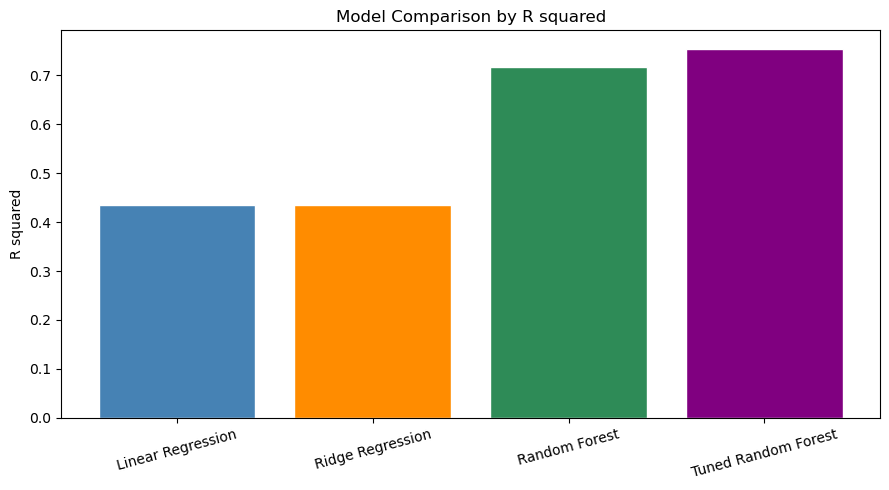

In [205]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Tuned Random Forest'],
    'RMSE': [lr_rmse, ridge_rmse, rf_rmse, rf_best_rmse],
    'R_squared': [lr_r2, ridge_r2, rf_r2, rf_best_r2]
}).round(4)
print(results.to_string(index=False))
plt.figure(figsize=(9, 5))
plt.bar(results['Model'], results['R_squared'], color=['steelblue', 'darkorange', 'seagreen', 'purple'], edgecolor='white')
plt.ylabel('R squared')
plt.title('Model Comparison by R squared')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

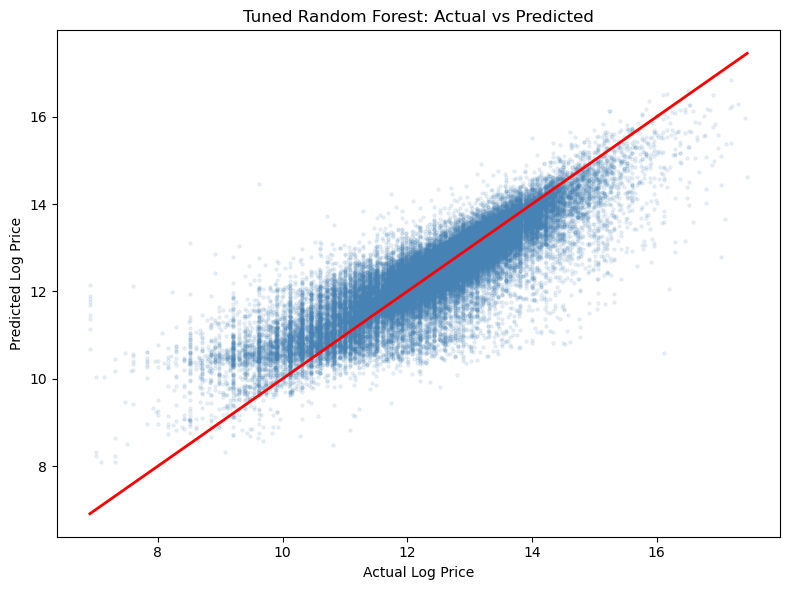

In [206]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_best_pred, alpha=0.1, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Tuned Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.show()

The scatter plot compares the actual log prices to the predictions from the best model. The red line is where a perfect prediction would fall. Most points cluster around the line, which shows the model captures the overall pattern well. The spread around the line represents the prediction error.

## 12. Feature Importance
The top three features are house_size (0.2317), median_hh_income (0.1641), and bath (0.1568). These confirm my EDA finding that property size, neighborhood wealth, and physical features drive listing price. I also fit the model on California alone (30,176 listings) to see whether a single-state model does better. It did — RMSE 0.4953 and R squared 0.7763, compared to 0.5595 and 0.7543 nationally which suggests price relationships differ enough between states that a national model gives up some accuracy.

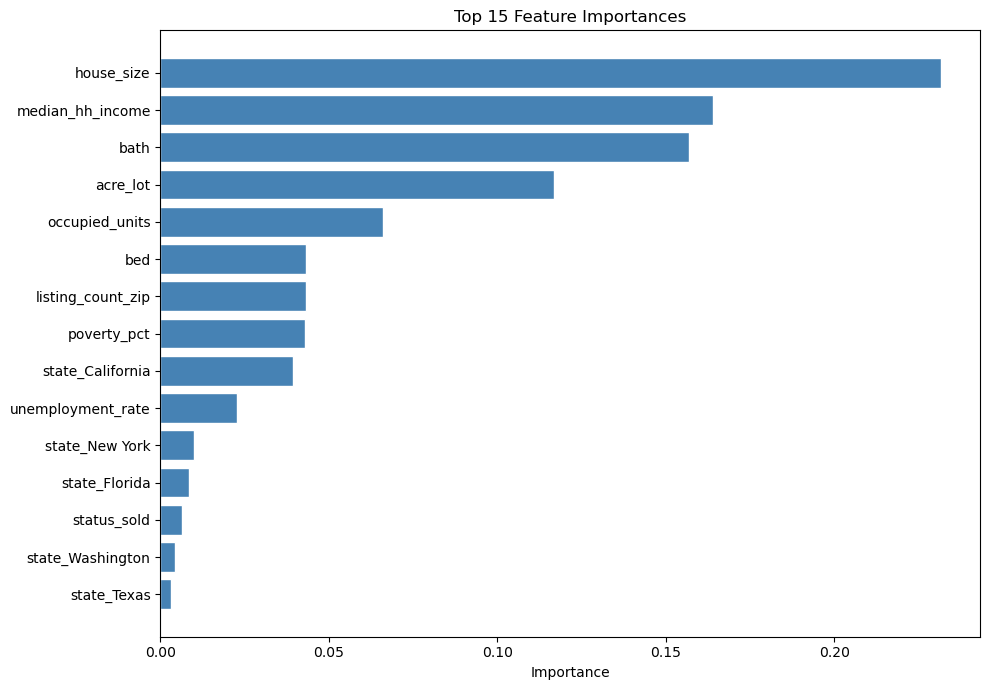

house_size           0.2317
median_hh_income     0.1641
bath                 0.1568
acre_lot             0.1168
occupied_units       0.0661
bed                  0.0432
listing_count_zip    0.0431
poverty_pct          0.0430
state_California     0.0392
unemployment_rate    0.0226
dtype: float64


In [209]:
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features.index, top_features.values, color='steelblue', edgecolor='white')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).head(10).round(4))

In [210]:
 %%time
ca = df[df['state'] == 'California']
print("California listings:", len(ca))
X_ca = pd.get_dummies(ca[['bed', 'bath', 'acre_lot', 'house_size', 'listing_count_zip',
                          'median_hh_income', 'unemployment_rate', 'poverty_pct',
                          'occupied_units', 'status']], columns=['status'], drop_first=True)
y_ca = ca['log_price']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_ca, y_ca, test_size=0.2, random_state=42)
num = ['bed', 'bath', 'acre_lot', 'house_size', 'listing_count_zip',
       'median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units']
sc = StandardScaler()
Xc_train[num] = sc.fit_transform(Xc_train[num])
Xc_test[num] = sc.transform(Xc_test[num])
rf_ca = RandomForestRegressor(**search.best_params_, random_state=42, n_jobs=-1)
rf_ca.fit(Xc_train, yc_train)
ca_pred = rf_ca.predict(Xc_test)
print("California only model")
print("RMSE:", round(np.sqrt(mean_squared_error(yc_test, ca_pred)), 4))
print("R squared:", round(r2_score(yc_test, ca_pred), 4))

California listings: 30176
California only model
RMSE: 0.4953
R squared: 0.7763
CPU times: user 20 s, sys: 812 ms, total: 20.8 s
Wall time: 3.41 s


The most important features confirm what I found in the EDA. Property characteristics carry the most weight - house size, bathrooms and lot size together account for roughly half the total importance. ZIP code economic features, led by median household income, add about a third. Location is a strong secondary signal rather than an equal one and it comes through the neighborhood economics far more than through the state dummies.

## 13. Conclusion
I completed the pre processing and modeling steps for my USA Real Estate capstone project.
Pre-processing. I sampled 300,000 rows from the 2.2 million row dataset to keep training times manageable. I created dummy variables for the two categorical columns, status and state, which expanded the feature set from 11 columns to 62. I standardized all nine numeric features with StandardScaler, fitting on the training data only. I split the data 80/20 into 238,372 training rows and 59,593 test rows. I used log price as my target because raw price is heavily right skewed, with a skewness of 15.45 that drops to -0.57 after the log transform.

Modeling:
Linear regression was my baseline, at an RMSE of 0.8491 and an R squared of 0.4341. Ridge regression produced identical numbers, which told me regularization was not the limiting factor. Random forest jumped to an RMSE of 0.6014 and an R squared of 0.7161, confirming that the relationship between these features and price is non linear. After comparing six parameter combinations, the tuned random forest at 1000 trees and depth 20 was the final winner with an RMSE of 0.5595 and an R squared of 0.7543.

Key findings:
House size (0.2317), ZIP code median household income (0.1641), and bathrooms (0.1568) are the strongest drivers of listing price, which matches what I found in the EDA. Individual state dummies contributed little once the ZIP-level economic columns were in the model, but a California-only model outperformed the national one, so state-level differences are real — they are just not well captured by a single dummy variable.

Limitations:
The model explains about 75 percent of the variation in log price, which leaves a quarter unexplained. Listings do not include condition, renovations, school district, or lot specifics, all of which affect price. I also selected hyperparameters against the test set rather than a separate validation set, so the final scores are somewhat optimistic.

Next steps:
Fit per-state or per-region models, given the California result. Add the ZIP code trajectory features from the 2019 versus 2023 Census comparison to predict which markets will appreciate. Try gradient boosting, which often outperforms random forest on tabular data like this.